# Benchmark ASR Y Tế: 5 Hệ Thống (Incremental Ablation)

Notebook này kiểm thử toàn diện độ chính xác **WER/CER**, **Entity F1**, và **Tốc độ (RTF)** trên 5 hệ thống ASR, theo cơ chế thêm dần từng thành phần (Incremental Ablation) để đo lường chính xác đóng góp của mỗi thành phần:

1. **S1 (Pretrained Baseline)**: `nguyenvulebinh/wav2vec2-base-vi-vlsp2020` + Greedy Decoding
2. **S2 (Fine-tuned)**: Custom Wav2Vec2 + Greedy Decoding *(Đo hiệu quả fine-tuning trên miền y tế)*
3. **S3 (S2 + Beam Search + Hotwords)**: *(Đo hiệu quả của từ điển biệt dược)*
4. **S4 (S3 + KenLM)**: *(Đo hiệu quả của mô hình ngôn ngữ 4-gram)*
5. **S5 (S4 + ViT5 Rewrite)**: *(Đo hiệu quả của mô hình Seq2Seq sửa lỗi và chuẩn hóa)*

**Đánh giá công bằng (Fair Evaluation):**
- **Layer A (Normalized)**: Áp dụng cho cả 5 hệ thống. Text được viết thường, loại bỏ dấu câu. Đo lường thuần túy năng lực ASR.
- **Layer B (Surface)**: Chỉ dùng cho S5 để đo lường khả năng khôi phục định dạng (viết hoa, dấu câu).


In [1]:
!pip install -q -U "transformers<4.40.0" "tokenizers<0.19.0" "accelerate<0.29.0" "peft==0.10.0" protobuf sentencepiece
!pip install -q --no-deps pyctcdecode kenlm jiwer pygtrie hypothesis rapidfuzz click

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.1/199.1 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 80.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 91.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.1/290.1 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 27.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
grpci

In [2]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")

from huggingface_hub import login 
login(hf_token)

In [3]:
import os
import re
import time
import string
import warnings
import torch
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
import jiwer
from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor, AutoTokenizer, AutoModelForSeq2SeqLM
from transformers import Wav2Vec2PreTrainedModel, Wav2Vec2Model
from pyctcdecode import build_ctcdecoder
from torch import nn
from collections import OrderedDict

warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("=" * 60)
print(f"Sử dụng thiết bị (Device): {device}")
if torch.cuda.is_available():
    print(f"Tên GPU: {torch.cuda.get_device_name(0)}")
print("=" * 60)

# --- TEXT NORMALIZATION ---
def normalize_for_eval(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def calculate_metrics(ref, hyp, normalize=True):
    if normalize:
        ref_eval = normalize_for_eval(ref)
        hyp_eval = normalize_for_eval(hyp)
    else:
        ref_eval = str(ref).strip()
        hyp_eval = str(hyp).strip()
        
    if not ref_eval:
        return 0.0, 0.0
    wer = jiwer.wer(ref_eval, hyp_eval)
    cer = jiwer.cer(ref_eval, hyp_eval)
    return wer, cer

# --- ENTITY EXTRACTION ---
def extract_entities(text, drug_set):
    norm_text = normalize_for_eval(text)
    entities = set()
    for d in drug_set:
        if d in norm_text:
            entities.add(d)
    return entities

def compute_entity_metrics(ref_entities, hyp_entities):
    if not ref_entities and not hyp_entities:
        return 1.0, 1.0, 1.0 # True negative
    if not hyp_entities or not ref_entities:
        return 0.0, 0.0, 0.0
        
    true_positive = len(ref_entities.intersection(hyp_entities))
    precision = true_positive / len(hyp_entities) if len(hyp_entities) > 0 else 0
    recall = true_positive / len(ref_entities) if len(ref_entities) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return precision, recall, f1


Sử dụng thiết bị (Device): cuda
Tên GPU: Tesla T4


In [4]:
import re
import string
from collections import Counter

CSV_PATH   = "/kaggle/input/datasets/tracvanngocphuc/medicaldialog/train_set/test_split.csv"
WAVS_DIR   = "/kaggle/input/datasets/tracvanngocphuc/medicaldialog/train_set/wavs"
DRUGS_PATH = "/kaggle/input/datasets/tracvanngocphuc/drugss/extracted_drugs_test.txt"
KENLM_PATH = "/kaggle/input/datasets/tracvanngocphuc/medlogmodel/models/kenlm+vit5/kenlm_vi_medical_4gram.bin"
VIT5_PATH  = "/kaggle/input/datasets/tracvanngocphuc/medlogmodel/models/kenlm+vit5/vit5_medical_rewrite_stage2_final"
WAV2VEC2_FINETUNED_PATH = "/kaggle/input/datasets/tracvanngocphuc/medlogmodel/models/asr"
CORPUS_PATH = "/kaggle/input/datasets/tracvanngocphuc/drugss/corpus.txt"

# Hàm trích xuất từ đơn từ corpus.txt để nạp làm từ điển (Unigrams) cho KenLM
def process_corpus(corpus_path, min_freq=2):
    unigrams_set = set()
    word_counts = Counter()
    if os.path.exists(corpus_path):
        with open(corpus_path, "r", encoding="utf-8") as f:
            for line in f:
                text = line.strip().lower()
                if not text:
                    continue
                text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
                words = re.sub(r"\s+", " ", text).strip().split()
                for w in words:
                    unigrams_set.add(w)
                word_counts.update(words)
    extracted_hotwords = [word for word, count in word_counts.items() if count >= min_freq and len(word) > 2]
    return list(unigrams_set), extracted_hotwords

# Tiến hành trích xuất từ corpus.txt TRƯỚC KHI tạo Decoder
unigrams_list, corpus_hotwords = process_corpus(CORPUS_PATH)

df_val = pd.read_csv(CSV_PATH)
df_val['audio_path'] = df_val['path'].apply(lambda x: Path(WAVS_DIR) / Path(x).name if (Path(WAVS_DIR) / Path(x).name).exists() else x)

HOTWORDS_MEDICAL = [line.strip() for line in open(DRUGS_PATH, "r", encoding="utf-8") if len(line.strip()) > 2]
final_hotwords = list(set(HOTWORDS_MEDICAL + corpus_hotwords))
DRUGS_SET = set([normalize_for_eval(w) for w in final_hotwords])

print(f"🚀 Đã chuẩn bị {len(unigrams_list):,} từ đơn sẵn sàng nạp cho KenLM!")

🚀 Đã chuẩn bị 55,031 từ đơn sẵn sàng nạp cho KenLM!


In [5]:
# --- CUSTOM WAV2VEC2 ARCHITECTURE (For Fine-tuned Model) ---
class CustomWav2Vec2ForCTC(Wav2Vec2PreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.wav2vec2 = Wav2Vec2Model(config)
        self.dropout = nn.Dropout(config.final_dropout)
        self.feature_transform = nn.Sequential(OrderedDict([
            ('linear1', nn.Linear(config.hidden_size, config.hidden_size)),
            ('bn1', nn.BatchNorm1d(config.hidden_size)),
            ('activation1', nn.LeakyReLU()),
            ('drop1', nn.Dropout(config.final_dropout)),
            ('linear2', nn.Linear(config.hidden_size, config.hidden_size)),
            ('bn2', nn.BatchNorm1d(config.hidden_size)),
            ('activation2', nn.LeakyReLU()),
            ('drop2', nn.Dropout(config.final_dropout)),
            ('linear3', nn.Linear(config.hidden_size, config.hidden_size)),
            ('bn3', nn.BatchNorm1d(config.hidden_size)),
            ('activation3', nn.LeakyReLU()),
            ('drop3', nn.Dropout(config.final_dropout))
        ]))
        if config.vocab_size is None:
            raise ValueError("config does not define vocab_size.")
        self.lm_head = nn.Linear(config.hidden_size, config.vocab_size)
        self.post_init()

    def forward(self, input_values, attention_mask=None, output_attentions=None, output_hidden_states=None, return_dict=None):
        return_dict = return_dict if return_dict is not None else self.config.use_return_dict
        outputs = self.wav2vec2(input_values, attention_mask=attention_mask, output_attentions=output_attentions, output_hidden_states=output_hidden_states, return_dict=return_dict)
        hidden_states = outputs[0]
        hidden_states = self.dropout(hidden_states)
        B, T, F = hidden_states.size()
        hidden_states = hidden_states.view(B * T, F)
        hidden_states = self.feature_transform(hidden_states)
        hidden_states = hidden_states.view(B, T, F)
        logits = self.lm_head(hidden_states)
        
        if not return_dict:
            output = (logits,) + outputs[2:]
            return output
        from transformers.modeling_outputs import CausalLMOutput
        return CausalLMOutput(loss=None, logits=logits, hidden_states=outputs.hidden_states, attentions=outputs.attentions)


In [6]:
# --- LOAD ALL MODELS ---
print("Đang tải các mô hình...")

# Processor chung
processor = Wav2Vec2Processor.from_pretrained("nguyenvulebinh/wav2vec2-base-vi-vlsp2020")

# S1: Pretrained Baseline
model_pretrained = Wav2Vec2ForCTC.from_pretrained("nguyenvulebinh/wav2vec2-base-vi-vlsp2020").to(device)
model_pretrained.eval()

# S2-S5: Custom Fine-tuned Model
print("Đang tải Custom Wav2Vec2 model từ checkpoint...")
try:
    import os, glob
    checkpoint_path = WAV2VEC2_FINETUNED_PATH
    
    # Kiểm tra xem có phải thư mục HuggingFace (.bin hoặc .safetensors) không
    is_hf_model = os.path.isdir(checkpoint_path) and (
        os.path.exists(os.path.join(checkpoint_path, "pytorch_model.bin")) or 
        os.path.exists(os.path.join(checkpoint_path, "model.safetensors"))
    )
    
    if is_hf_model:
        print(f"Loading weights directly from HuggingFace directory {checkpoint_path}...")
        model_finetuned = CustomWav2Vec2ForCTC.from_pretrained(checkpoint_path).to(device)
    else:
        # Khởi tạo cấu trúc mô hình custom từ pretrained base
        model_finetuned = CustomWav2Vec2ForCTC.from_pretrained(
            "nguyenvulebinh/wav2vec2-base-vi-vlsp2020",
            pad_token_id=processor.tokenizer.pad_token_id,
            vocab_size=len(processor.tokenizer)
        )
        
        if os.path.isdir(checkpoint_path):
            pt_files = glob.glob(os.path.join(checkpoint_path, "*.pt*"))
            if pt_files:
                checkpoint_path = pt_files[0]
            else:
                raise FileNotFoundError(f"Không tìm thấy file .pt hay thư mục HF model hợp lệ trong {checkpoint_path}")
                
        print(f"Loading weights from PyTorch checkpoint {checkpoint_path}...")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        
        # Hỗ trợ cả 2 định dạng checkpoint
        if 'model_state' in checkpoint:
            model_finetuned.load_state_dict(checkpoint['model_state'])
        else:
            model_finetuned.load_state_dict(checkpoint)
            
        model_finetuned = model_finetuned.to(device)
    
    print("✅ Tải Custom model thành công!")
except Exception as e:
    print(f"Không thể tải Custom model, fallback sang Wav2Vec2ForCTC base: {e}")
    model_finetuned = Wav2Vec2ForCTC.from_pretrained("nguyenvulebinh/wav2vec2-base-vi-vlsp2020").to(device)

model_finetuned.eval()

# Pyctcdecode
vocab_dict = processor.tokenizer.get_vocab()
sorted_vocab = sorted((value, key) for (key, value) in vocab_dict.items())

vocab_list = []
for value, key in sorted_vocab:
    if key == "|":
        vocab_list.append(" ")
    elif len(key) > 1:
        # Giữ nguyên các token đặc biệt (ví dụ: <pad>, <s>, </s>) nhưng loại bỏ các ký tự dấu đóng mở nhọn 
        # và thêm vào một tiền tố đặc biệt để không bao giờ trùng với chữ cái tiếng Việt thường.
        # Ví dụ: "<s>" -> "[s]", "</s>" -> "[/s]", "<pad>" -> "[pad]"
        clean_key = f"[{key.replace('<', '').replace('>', '')}]"
        vocab_list.append(clean_key)
    else:
        vocab_list.append(key)

vocab_list = vocab_list[:model_pretrained.config.vocab_size]

# Đặt đoạn này ở cuối ô nạp Model và Vocab (Cell 41)
decoder_no_lm = build_ctcdecoder(labels=vocab_list, kenlm_model_path=None)

# Lúc này unigrams_list đã có 55,031 từ, truyền vào đây KenLM sẽ chạy cực kỳ chuẩn!
decoder_kenlm = build_ctcdecoder(
    labels=vocab_list, 
    kenlm_model_path=KENLM_PATH, # File .bin chuẩn của bạn
    unigrams=unigrams_list,       # Vốn từ vựng chuẩn từ corpus[cite: 4]
    alpha=0.15,                  # Hạ xuống 0.15 - 0.2 để KenLM sửa lỗi nhẹ nhàng, không bẻ từ bừa bãi[cite: 4]
    beta=1.0     
)
print("✅ Hệ thống Decoder hoàn tất nạp file .bin và từ điển Unigrams!")

# ViT5
vit5_tokenizer = AutoTokenizer.from_pretrained(VIT5_PATH)
vit5_model = AutoModelForSeq2SeqLM.from_pretrained(VIT5_PATH).to(device)
vit5_model.eval()

print("Hoàn tất tải toàn bộ hệ thống!")

Đang tải các mô hình...


preprocessor_config.json:   0%|          | 0.00/263 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/30.0 [00:00<?, ?B/s]

...

Loading weights from PyTorch checkpoint /kaggle/input/datasets/tracvanngocphuc/medlogmodel/models/asr/best_model.pt...


Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?


✅ Tải Custom model thành công!


Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?
Unigrams and labels don't seem to agree.


✅ Hệ thống Decoder hoàn tất nạp file .bin và từ điển Unigrams!
Hoàn tất tải toàn bộ hệ thống!


In [7]:
# --- MAIN BENCHMARK LOOP ---
detailed_logs = []
print(f"Bắt đầu chạy benchmark trên {len(df_val)} mẫu...")

total_audio_duration = 0.0
time_s1, time_s2, time_s3, time_s4, time_s5 = 0.0, 0.0, 0.0, 0.0, 0.0

BEAM_WIDTH = 16
BEAM_PRUNE_LOGP = -5.0
TOKEN_MIN_LOGP = -3.0
HOTWORD_WEIGHT = 3.0

# [QUAN TRỌNG] Rút gọn danh sách hotwords nếu quá dài để tránh treo pyctcdecode 
hotwords_subset = HOTWORDS_MEDICAL[:500] if len(HOTWORDS_MEDICAL) > 500 else HOTWORDS_MEDICAL
print(f"Sử dụng {len(hotwords_subset)} hotwords cho decoding để tránh quá tải CPU.")

for idx, row in tqdm(df_val.iterrows(), total=len(df_val), desc="Benchmarking 5 Systems"):
    audio_path = row['audio_path']
    ref_text = str(row['text']) if pd.notnull(row['text']) else ""
    ref_entities = extract_entities(ref_text, DRUGS_SET)
    
    if not os.path.exists(audio_path):
        continue
        
    speech, sr = librosa.load(audio_path, sr=16000)
    audio_duration = len(speech) / sr
    total_audio_duration += audio_duration
    
    inputs = processor(speech, sampling_rate=16000, return_tensors="pt", padding=True)
    input_values = inputs.input_values.to(device)
    
    # --- LOGITS EXTRACTION ---
    start_t = time.time()
    with torch.inference_mode():
        logits_pt = model_pretrained(input_values).logits[0]
    time_model_pt = time.time() - start_t
    
    start_t = time.time()
    with torch.inference_mode():
        logits_ft = model_finetuned(input_values).logits[0]
    time_model_ft = time.time() - start_t
    logits_ft_np = logits_ft.cpu().numpy()
    
    # --- DECODING ---
    start_t = time.time()
    trans_s1 = processor.decode(torch.argmax(logits_pt, dim=-1))
    time_s1 += (time_model_pt + time.time() - start_t)
    
    start_t = time.time()
    trans_s2 = processor.decode(torch.argmax(logits_ft, dim=-1))
    time_s2 += (time_model_ft + time.time() - start_t)
    
    # Thêm tham số Pruning: beam_prune_logp và token_min_logp
    start_t = time.time()
    trans_s3 = decoder_no_lm.decode(
        logits_ft_np, 
        beam_width=BEAM_WIDTH, 
        beam_prune_logp=BEAM_PRUNE_LOGP,
        token_min_logp=TOKEN_MIN_LOGP,
        hotwords=hotwords_subset, 
        hotword_weight=HOTWORD_WEIGHT
    )
    time_s3 += (time_model_ft + time.time() - start_t)
    
    # Thêm tham số Pruning: beam_prune_logp và token_min_logp
    start_t = time.time()
    trans_s4 = decoder_kenlm.decode(
        logits_ft_np, 
        beam_width=BEAM_WIDTH, 
        beam_prune_logp=BEAM_PRUNE_LOGP,
        token_min_logp=TOKEN_MIN_LOGP,
        hotwords=hotwords_subset, 
        hotword_weight=HOTWORD_WEIGHT
    )
    time_s4 += (time_model_ft + time.time() - start_t)
    
    start_t = time.time()
    vit5_inputs = vit5_tokenizer(trans_s4, return_tensors="pt", max_length=256, truncation=True).to(device)
    
    with torch.inference_mode():
        vit5_outputs = vit5_model.generate(
            **vit5_inputs, 
            num_beams=4,                 # Tăng lại lên 4 beam để tìm kiếm tốt hơn
            max_new_tokens=150,          # Ép mô hình sinh ra tối đa 150 token, không bị cắt cụt câu
            min_length=len(trans_s4.split()) - 5, # Khống chế độ dài tối thiểu gần bằng câu gốc của ASR
            repetition_penalty=1.2,      
            early_stopping=False         # Tắt early_stopping để tránh việc dừng sinh mã quá sớm
        )
    trans_s5 = vit5_tokenizer.decode(vit5_outputs[0], skip_special_tokens=True)
    time_s5 += (time_s4 - time_model_ft) + (time_model_ft + time.time() - start_t)
    
    # --- EVALUATION ---
    systems = {'s1': trans_s1, 's2': trans_s2, 's3': trans_s3, 's4': trans_s4, 's5': trans_s5}
    
    log_entry = {'sample_id': os.path.basename(audio_path), 'duration': audio_duration, 'ref_text': ref_text}
    
    for s_name, trans in systems.items():
        wer, cer = calculate_metrics(ref_text, trans, normalize=True)
        hyp_entities = extract_entities(trans, DRUGS_SET)
        p, r, f1 = compute_entity_metrics(ref_entities, hyp_entities)
        
        log_entry[f'{s_name}_trans'] = trans
        log_entry[f'{s_name}_wer_norm'] = wer
        log_entry[f'{s_name}_cer_norm'] = cer
        log_entry[f'{s_name}_ent_f1'] = f1
        log_entry[f'{s_name}_ent_p'] = p
        log_entry[f'{s_name}_ent_r'] = r
        
        if s_name == 's5':
            wer_surf, cer_surf = calculate_metrics(ref_text, trans, normalize=False)
            log_entry[f'{s_name}_wer_surf'] = wer_surf
            log_entry[f'{s_name}_cer_surf'] = cer_surf
            
    detailed_logs.append(log_entry)

df_logs = pd.DataFrame(detailed_logs)
print("Hoàn tất benchmark!")

Bắt đầu chạy benchmark trên 200 mẫu...
Sử dụng 81 hotwords cho decoding để tránh quá tải CPU.


Benchmarking 5 Systems:   0%|          | 0/200 [00:00<?, ?it/s]

Hoàn tất benchmark!


In [8]:
# --- SUMMARY TABLES ---
sys_names = [
    "S1 (Pretrained Baseline)",
    "S2 (Fine-tuned Greedy)",
    "S3 (S2 + Beam + Hotwords)",
    "S4 (S3 + KenLM)",
    "S5 (S4 + ViT5 Rewrite)"
]
sys_keys = ['s1', 's2', 's3', 's4', 's5']
times = [time_s1, time_s2, time_s3, time_s4, time_s5]

summary_data = []
for i, (name, key, t) in enumerate(zip(sys_names, sys_keys, times)):
    summary_data.append({
        "System": name,
        "Norm WER (%)": round(df_logs[f'{key}_wer_norm'].mean() * 100, 2),
        "Norm CER (%)": round(df_logs[f'{key}_cer_norm'].mean() * 100, 2),
        "Entity F1 (%)": round(df_logs[f'{key}_ent_f1'].mean() * 100, 2),
        "Entity Precision (%)": round(df_logs[f'{key}_ent_p'].mean() * 100, 2),
        "Entity Recall (%)": round(df_logs[f'{key}_ent_r'].mean() * 100, 2),
        "RTF": round(t / total_audio_duration, 4)
    })

df_summary = pd.DataFrame(summary_data)
display(df_summary)

print("\n=== Tác động của ViT5 (S5) lên định dạng (Layer B - Surface) ===")
print(f"S5 Surface WER: {df_logs['s5_wer_surf'].mean()*100:.2f}% (so với Normalized WER: {df_logs['s5_wer_norm'].mean()*100:.2f}%)")
print(f"S5 Surface CER: {df_logs['s5_cer_surf'].mean()*100:.2f}% (so với Normalized CER: {df_logs['s5_cer_norm'].mean()*100:.2f}%)")

,System,Norm WER (%),Norm CER (%),Entity F1 (%),Entity Precision (%),Entity Recall (%),RTF
0,S1 (Pretrained Baseline),112.02,218.44,0.00,0.00,0.00,0.0019
1,S2 (Fine-tuned Greedy),44.50,26.42,65.51,73.75,59.70,0.0009
2,S3 (S2 + Beam + Hotwords),42.59,25.99,66.06,74.30,60.26,0.1372
3,S4 (S3 + KenLM),35.87,25.84,69.39,77.86,63.47,0.0098
4,S5 (S4 + ViT5 Rewrite),37.88,31.01,68.53,75.17,63.83,1.0800



=== Tác động của ViT5 (S5) lên định dạng (Layer B - Surface) ===
S5 Surface WER: 44.43% (so với Normalized WER: 37.88%)
S5 Surface CER: 33.20% (so với Normalized CER: 31.01%)


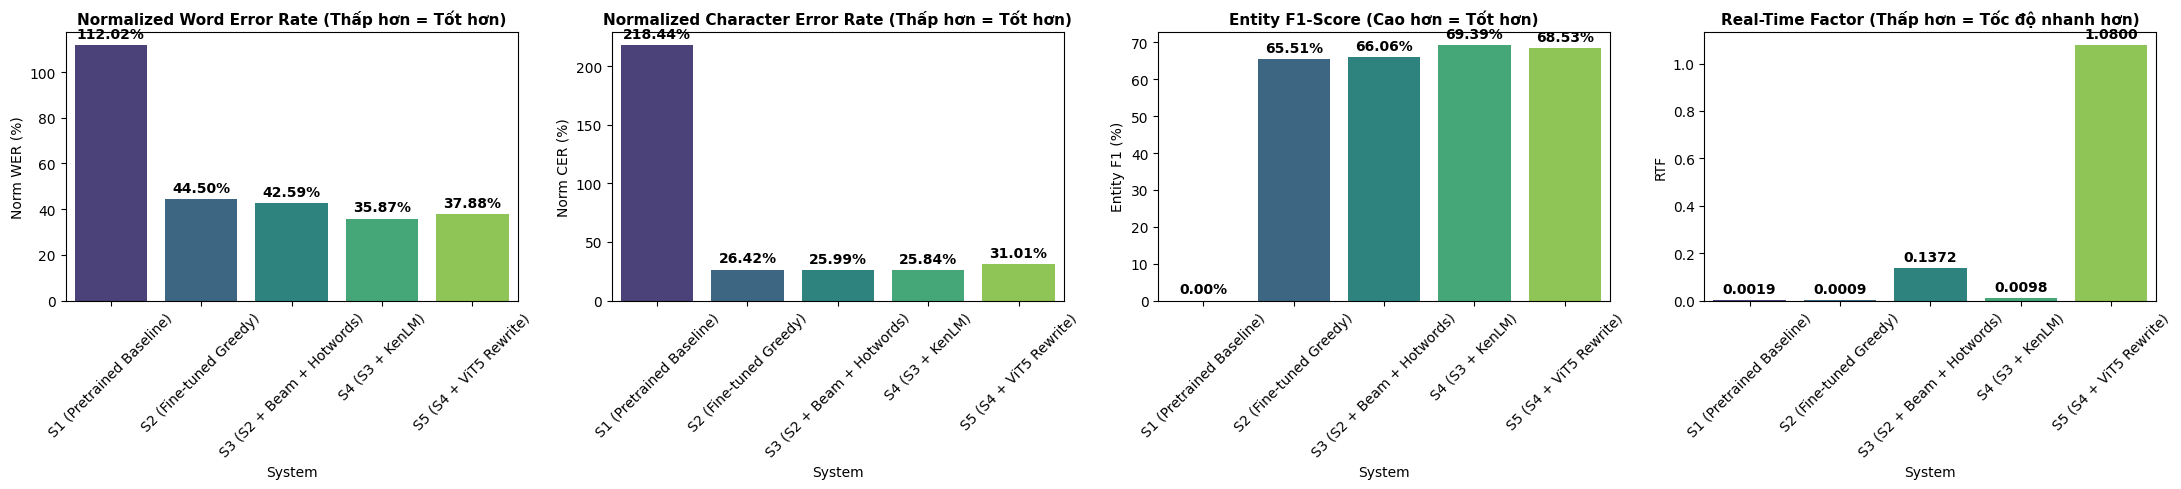

In [9]:
# --- VISUALIZATIONS ---
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
palette = "viridis"

metrics = [
    ("Norm WER (%)", "Normalized Word Error Rate (Thấp hơn = Tốt hơn)"),
    ("Norm CER (%)", "Normalized Character Error Rate (Thấp hơn = Tốt hơn)"),
    ("Entity F1 (%)", "Entity F1-Score (Cao hơn = Tốt hơn)"),
    ("RTF", "Real-Time Factor (Thấp hơn = Tốc độ nhanh hơn)")
]

for i, (col, title) in enumerate(metrics):
    sns.barplot(data=df_summary, x="System", y=col, ax=axes[i], palette=palette)
    axes[i].set_title(title, fontsize=11, fontweight="bold")
    axes[i].tick_params(axis='x', rotation=45)
    for p in axes[i].patches:
        val = p.get_height()
        text = f"{val:.2f}%" if "RTF" not in col else f"{val:.4f}"
        axes[i].annotate(text, (p.get_x() + p.get_width() / 2., val),
                         ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight="bold")

plt.tight_layout()
plt.show()


In [10]:
# --- EXAMPLES ---
print("\n=== VÍ DỤ ĐIỂN HÌNH SO SÁNH 5 HỆ THỐNG ===")
for _, row in df_logs.head(5).iterrows():
    print(f"\n[File: {row['sample_id']}]")
    print(f" 🔹 Reference  : {row['ref_text']}")
    print(f" 🔸 S1 Baseline: {row['s1_trans']} (Norm WER: {row['s1_wer_norm']*100:.1f}%)")
    print(f" 🔸 S2 Finetune: {row['s2_trans']} (Norm WER: {row['s2_wer_norm']*100:.1f}%)")
    print(f" 🔸 S3 Beam+HW : {row['s3_trans']} (Norm WER: {row['s3_wer_norm']*100:.1f}%)")
    print(f" 🔸 S4 KenLM   : {row['s4_trans']} (Norm WER: {row['s4_wer_norm']*100:.1f}%)")
    print(f" 🚀 S5 ViT5    : {row['s5_trans']} (Norm WER: {row['s5_wer_norm']*100:.1f}%)")
    print("-" * 80)



=== VÍ DỤ ĐIỂN HÌNH SO SÁNH 5 HỆ THỐNG ===

[File: voice-2848.wav]
 🔹 Reference  : so với cortisol thể tích phân bố của tixocortol được ghi nhận lớn hơn bao nhiêu số liệu này có ý nghĩa gì về mặt dược động học
 🔸 S1 Baseline: jẵjẵjẵjfĩòờỏẵũắụplxfỵẵặẩ<unk>ỵẩẵjpứỳỵẵõpẵặụcủcpẵặẩăiụịẵkủpẵzặũ<unk>f pẵzjzjợjđflẵjặẩ<unk>ỵẩẵfjfkứỳỵỳ ỏẵxzjfỵ ờzjặỵỳẩỏỵ ẵõờpẵặờỵlđẵzặễỵ<unk>ẳẩỏẵ ăẵặòứòẵjòzjặỷủ<unk>ủpđpẵầừpđẵấiũẵẽ<unk>òủhõẵjủẩắữỳõfẵjfờ ỳỏẵẩầờmỳõẵzởỵdõẵêậờỳồò<unk>ổìẵặjwd<unk> ớẵzd<unk> mẵzfắmẵzặẹỵẵzjhj<unk>xzjfẵfẻẽởỵẵđfjẵjẵ (Norm WER: 100.0%)
 🔸 S2 Finetune: so với cotison giải thích phon bố của tisocoto được ghinhận lớn hơn bao nhiu số liệu này có ý nghĩa gì về mặt dục động học (Norm WER: 32.1%)
 🔸 S3 Beam+HW : so với cotison giải thích phon bố của tixocortol được ghi nhận lớn hơn bao nhiu số liệu này có ý nghĩa gì về mặt dục động học (Norm WER: 21.4%)
 🔸 S4 KenLM   : so với cotton giải thích phân bố của tixocortol được ghi nhận lớn hơn bao nhiêu số liệu này có ý nghĩa gì về mặt dục động học (Norm